# Линейная регрессия — датасет California Housing

В данном ноутбуке демонстрируется применение `LinearRegression` из библиотеки **numl**
для предсказания медианной стоимости жилья в Калифорнии.

**Структура ноутбука:**
1. Загрузка и разведочный анализ данных  
2. Предобработка: стандартизация признаков  
3. Обучение трёмя методами: `sgd`, `gd`, `norm_eq`  
4. Сравнение кривых потерь  
5. Оценка качества (R²) на тестовой выборке

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Импорт модели из локального пакета
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from numl import LinearRegression

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Загрузка данных

In [30]:
data = fetch_california_housing(as_frame=True)
df = data.frame

print(f"Размер датасета: {df.shape}")
print(f"Признаки: {list(data.feature_names)}")
df.head()

Размер датасета: (20640, 9)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


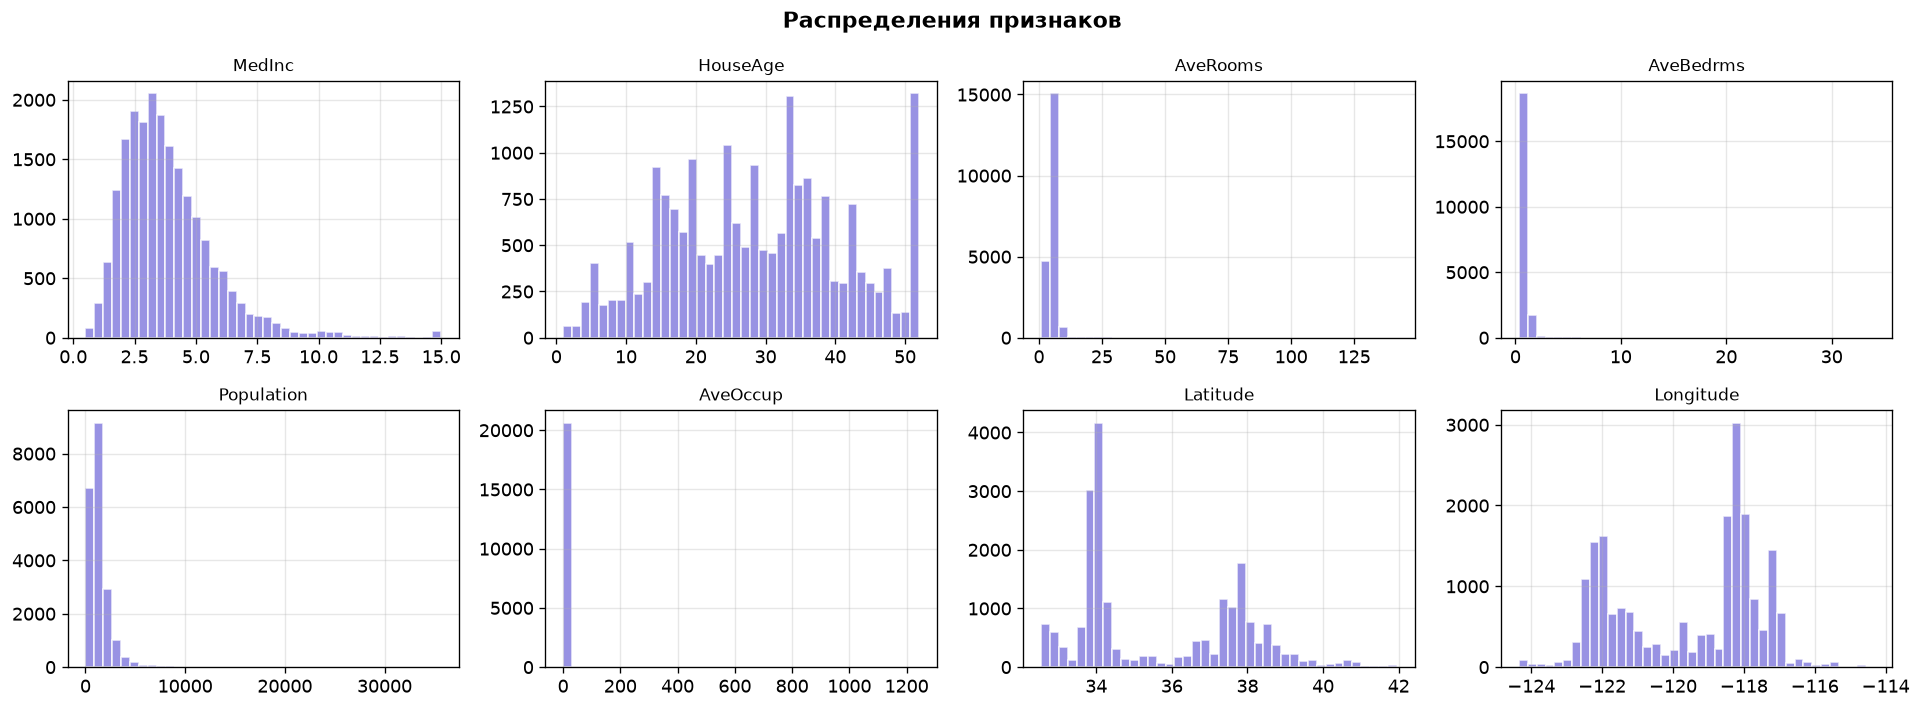

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.ravel(), data.feature_names):
    ax.hist(df[col], bins=40, color="#7F77DD", alpha=0.8, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.grid(True, alpha=0.3)
plt.suptitle("Распределения признаков", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Предобработка

In [32]:
X = df[data.feature_names].values
y = data.target.values  # медианная стоимость, $100k

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train_sc.shape}")
print(f"Тестовая выборка:  {X_test_sc.shape}")

Обучающая выборка: (16512, 8)
Тестовая выборка:  (4128, 8)


## 3. Обучение тремя методами

In [33]:
# Нормальное уравнение — аналитическое решение, без итераций
model_ne = LinearRegression(method="norm_eq")
model_ne.fit(X_train_sc, y_train)
print(f"norm_eq  | R² test = {model_ne.score(X_test_sc, y_test):.4f}")

norm_eq  | R² test = 0.5758


In [34]:
# Полный градиентный спуск
model_gd = LinearRegression(method="gd", lr=0.1, epochs=300)
model_gd.fit(X_train_sc, y_train)
print(f"gd       | R² test = {model_gd.score(X_test_sc, y_test):.4f}  "
      f"| эпох: {len(model_gd.loss_history)}")

gd       | R² test = 0.5766  | эпох: 300


In [35]:
# Mini-batch SGD
model_sgd = LinearRegression(method="sgd", lr=0.01, epochs=300, batch_size=64)
model_sgd.fit(X_train_sc, y_train)
print(f"sgd      | R² test = {model_sgd.score(X_test_sc, y_test):.4f}  "
      f"| эпох: {len(model_sgd.loss_history)}")

sgd      | R² test = 0.5696  | эпох: 300


## 4. Кривые потерь

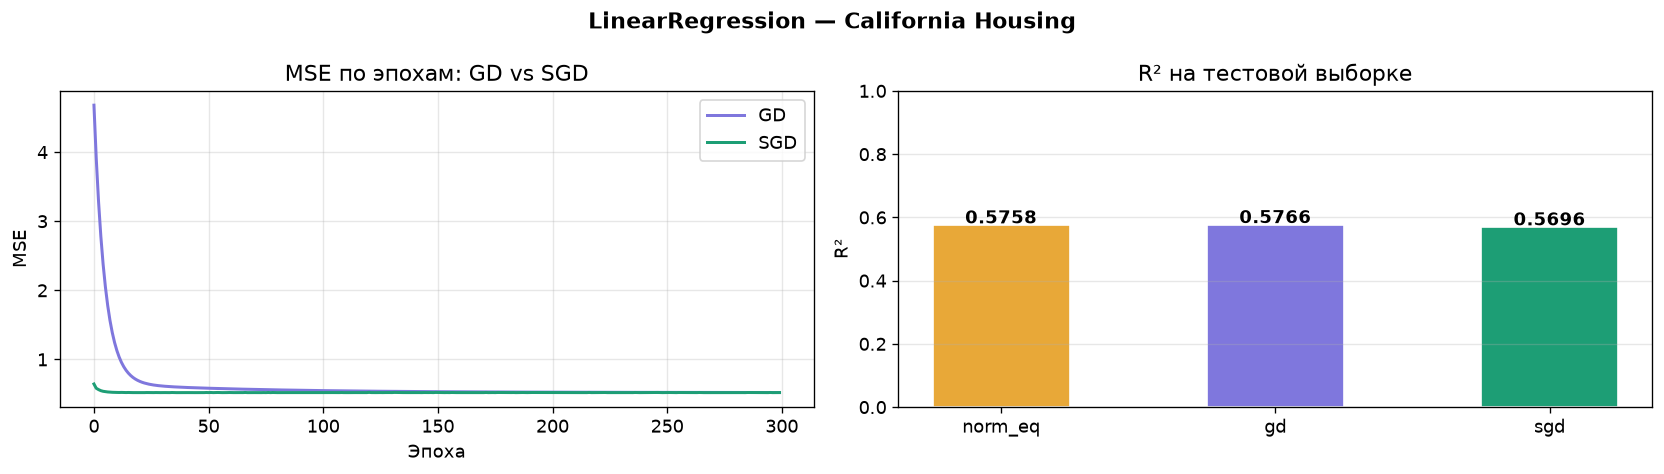

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# GD vs SGD
for model, label, color in [
    (model_gd,  "GD",  "#7F77DD"),
    (model_sgd, "SGD", "#1D9E75"),
]:
    axes[0].plot(model.loss_history, label=label, color=color, linewidth=1.8)
axes[0].set_title("MSE по эпохам: GD vs SGD")
axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("MSE")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Сравнение R² на тесте
names  = ["norm_eq", "gd", "sgd"]
scores = [model_ne.score(X_test_sc, y_test),
          model_gd.score(X_test_sc, y_test),
          model_sgd.score(X_test_sc, y_test)]
colors = ["#E8A838", "#7F77DD", "#1D9E75"]
bars = axes[1].bar(names, scores, color=colors, width=0.5, edgecolor="white")
for bar, s in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, s + 0.005,
                 f"{s:.4f}", ha="center", fontweight="bold")
axes[1].set_ylim(0, 1); axes[1].set_ylabel("R²")
axes[1].set_title("R² на тестовой выборке")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("LinearRegression — California Housing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Анализ остатков

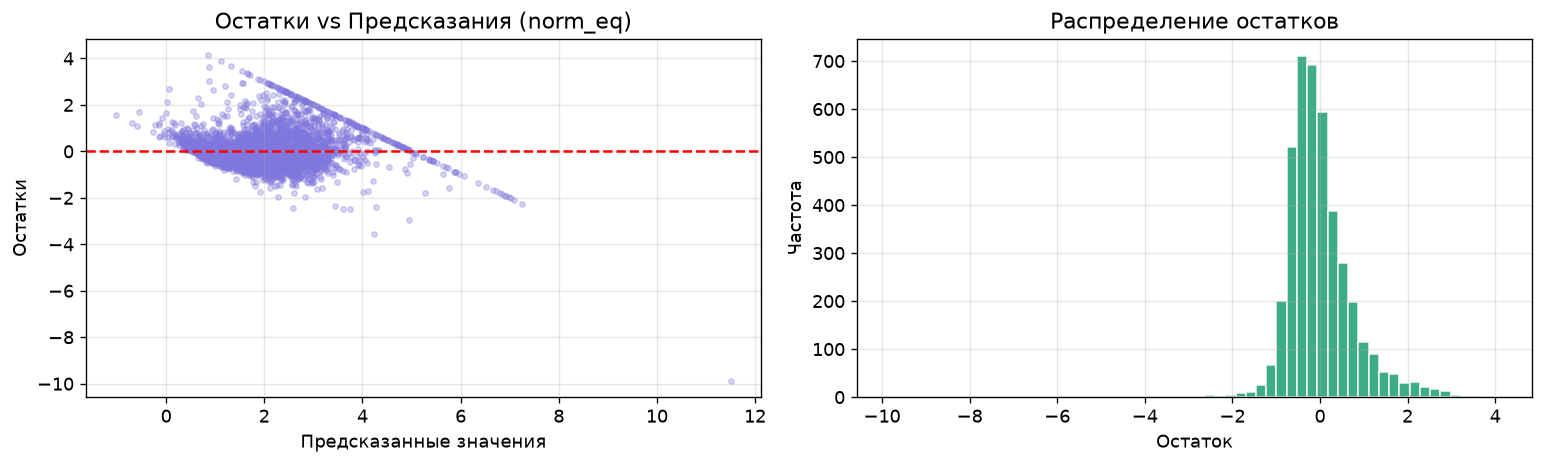

Среднее остатков:     0.003479
Стд. откл. остатков: 0.7456


In [37]:
y_pred = model_ne.predict(X_test_sc)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=10, color="#7F77DD")
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Предсказанные значения"); axes[0].set_ylabel("Остатки")
axes[0].set_title("Остатки vs Предсказания (norm_eq)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=60, color="#1D9E75", alpha=0.85, edgecolor="white")
axes[1].set_xlabel("Остаток"); axes[1].set_ylabel("Частота")
axes[1].set_title("Распределение остатков")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Среднее остатков:     {residuals.mean():.6f}")
print(f"Стд. откл. остатков: {residuals.std():.4f}")

## Выводы

| Метод     | R² (тест) | Особенности |
|-----------|-----------|-------------|
| `norm_eq` | наивысший | Аналитическое решение; точно, но O(d³) по памяти |
| `gd`      | близко к norm_eq | Гладкая кривая loss, медленнее на больших данных |
| `sgd`     | близко к norm_eq | Зашумлённая кривая, быстрее сходится на больших выборках |

Для задач регрессии на датасетах среднего размера `norm_eq` является предпочтительным выбором.
На больших данных (> 10⁵ объектов) рекомендуется использовать `sgd`.